# 🇵🇭 Philippine Energy Consumption Analysis (2003–2024)

Author: Engr. John Paul Villaban  
Data Source: Department of Energy Philippines — [doe.gov.ph](https://doe.gov.ph)  
Last Updated: 2024

---

## 📌 Project Overview

This project analyzes over **two decades of electricity consumption data** in the Philippines using Python and pandas. The goal is to uncover trends, regional differences, and seasonal patterns in Philippine energy demand.

### 🎯 Key Questions This Analysis Answers:
1. How has electricity demand grown in the Philippines from 2003 to 2024?
2. Which region generates and consumes the most power?
3. Which months have the highest electricity usage and why?
4. How has the energy mix (coal vs renewables) shifted over time?

### 📂 Datasets Used:
| File | Description |
|------|-------------|
| `yearly_consumption.csv` | Annual electricity consumption by sector (2003–2024) |
| `regional_generation.csv` | Power generation by grid: Luzon, Visayas, Mindanao |
| `monthly_consumption_2024.csv` | Monthly breakdown by region and sector (2024) |
| `generation_by_plant_type.csv` | Generation by source: coal, gas, renewables (2003–2024) |

---
## ⚙️ Part 1: Import Libraries

We start by importing the libraries we need:
- **pandas** — for loading and manipulating data
- **matplotlib** — for creating charts and visualizations
- **os** — for creating output folders to save charts

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Create output folder for saving charts
os.makedirs('output', exist_ok=True)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Part 2: Load the Data

We load all four CSV files into separate DataFrames. Each file covers a different aspect of Philippine energy data:

- `yearly` → long-term consumption trend from 2003 to 2024
- `regional` → how much each grid (Luzon, Visayas, Mindanao) generates
- `monthly` → month-by-month breakdown for 2024
- `plants` → what type of power source generated the electricity (coal, gas, renewables)

In [50]:
yearly   = pd.read_csv('/kaggle/input/datasets/johnpolv/philippineenergydatasets/yearly_consumption.csv')
regional = pd.read_csv('/kaggle/input/datasets/johnpolv/philippineenergydatasets/regional_generation.csv')
monthly  = pd.read_csv('/kaggle/input/datasets/johnpolv/philippineenergydatasets/monthly_consumption_2024.csv')
plants   = pd.read_csv('/kaggle/input/datasets/johnpolv/philippineenergydatasets/generation_by_plant_type.csv')

print('✅ All datasets loaded successfully!')

✅ All datasets loaded successfully!


---
## 🔍 Part 3: Explore the Data

Before analyzing, we need to understand what our data looks like. This step answers:
- How many rows and columns does each dataset have?
- What are the column names?
- Are there any missing values we need to handle?
- What data types are the columns?

This is called **Exploratory Data Analysis (EDA)** and is always the first step in any data project.

In [51]:
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)

print('\n📋 Yearly Consumption — Shape:', yearly.shape)
print(yearly.head())

print('\n📋 Regional Generation — Shape:', regional.shape)
print(regional.head())

print('\n📋 Monthly 2024 — Shape:', monthly.shape)
print(monthly.head())

print('\n📋 Data Types (yearly):')
print(yearly.dtypes)

print('\n📋 Missing Values:')
print(yearly.isnull().sum())

DATASET OVERVIEW

📋 Yearly Consumption — Shape: (22, 9)
   year  residential_gwh  commercial_gwh  industrial_gwh  others_gwh  \
0  2003            15357           11106           15188        1069   
1  2004            15920           11785           15012        1359   
2  2005            16031           12245           15705        1177   
3  2006            15830           12679           15888        1275   
4  2007            16376           13470           16522        1641   

   total_sales_gwh  utilities_own_use_gwh  system_losses_gwh  \
0            42720                   3410               6810   
1            44076                   4654               7228   
2            45159                   4591               6817   
3            45672                   4227               6885   
4            48009                   3994               7608   

   total_consumption_gwh  
0                  52941  
1                  55957  
2                  56568  
3                 

---
## 🧹 Part 4: Clean the Data

Real-world data is often messy. In this step we:
- **Strip and lowercase column names** — removes accidental spaces and makes column names consistent
- **Drop empty rows** — removes rows where all values are missing (NaN)

Even though our CSV files are already clean, it is always good practice to include a cleaning step in every project.

In [52]:
# Standardize column names
yearly.columns   = yearly.columns.str.strip().str.lower()
regional.columns = regional.columns.str.strip().str.lower()
monthly.columns  = monthly.columns.str.strip().str.lower()
plants.columns   = plants.columns.str.strip().str.lower()

# Drop fully empty rows
yearly   = yearly.dropna(how='all')
regional = regional.dropna(how='all')

print('✅ Data cleaned successfully!')
print('Yearly shape after cleaning:', yearly.shape)
print('Regional shape after cleaning:', regional.shape)

✅ Data cleaned successfully!
Yearly shape after cleaning: (22, 9)
Regional shape after cleaning: (22, 5)


---
## 📊 Part 5: Analysis 1 — Electricity Demand Trend (2003–2024)

We look at how total electricity consumption in the Philippines has changed year by year.

We also calculate the **year-over-year percentage change** to measure how fast demand is growing. A notable dip is expected in **2020** due to the COVID-19 pandemic, when lockdowns significantly reduced commercial and industrial activity.

In [53]:
print('=' * 55)
print('ANALYSIS 1: ELECTRICITY DEMAND TREND (2003-2024)')
print('=' * 55)

print(yearly[['year', 'total_consumption_gwh']])

# Year-over-year percentage change
yearly['pct_change'] = yearly['total_consumption_gwh'].pct_change() * 100

print('\n📈 Year-over-Year Growth Rate (%):')
print(yearly[['year', 'pct_change']].dropna().round(2).to_string(index=False))

print(f'\n🔢 Average Annual Growth Rate: {yearly["pct_change"].mean():.2f}%')
print(f'📌 Highest Consumption Year: {yearly.loc[yearly["total_consumption_gwh"].idxmax(), "year"]}')
print(f'📌 Lowest Consumption Year:  {yearly.loc[yearly["total_consumption_gwh"].idxmin(), "year"]}')

ANALYSIS 1: ELECTRICITY DEMAND TREND (2003-2024)
    year  total_consumption_gwh
0   2003                  52941
1   2004                  55957
2   2005                  56568
3   2006                  56784
4   2007                  59612
5   2008                  60821
6   2009                  61934
7   2010                  67743
8   2011                  69176
9   2012                  72922
10  2013                  75266
11  2014                  77261
12  2015                  82413
13  2016                  90798
14  2017                  94370
15  2018                  99765
16  2019                 106041
17  2020                 101756
18  2021                 106115
19  2022                 111516
20  2023                 118004
21  2024                 126941

📈 Year-over-Year Growth Rate (%):
 year  pct_change
 2004        5.70
 2005        1.09
 2006        0.38
 2007        4.98
 2008        2.03
 2009        1.83
 2010        9.38
 2011        2.12
 2012        5.42


---
## 🗺️ Part 6: Analysis 2 — Regional Power Generation (2024)

The Philippines is divided into three major power grids:
- **Luzon** — the largest grid, covering Metro Manila and surrounding provinces
- **Visayas** — covers the central island group
- **Mindanao** — covers the southern island group

We compare how much power each grid generated in 2024 to understand which region drives the most electricity demand.

In [54]:
print('=' * 55)
print('ANALYSIS 2: REGIONAL POWER GENERATION (2024)')
print('=' * 55)

# Get 2024 regional data
latest = regional[regional['year'] == 2024][['luzon_gwh', 'visayas_gwh', 'mindanao_gwh']]
region_2024 = pd.Series({
    'Luzon':    latest['luzon_gwh'].values[0],
    'Visayas':  latest['visayas_gwh'].values[0],
    'Mindanao': latest['mindanao_gwh'].values[0]
}).sort_values(ascending=False)

print('\n⚡ 2024 Power Generation by Region (GWh):')
print(region_2024.to_string())
print(f'\n🏆 Top Region:    {region_2024.index[0]} ({region_2024.iloc[0]:,.0f} GWh)')
print(f'📉 Lowest Region: {region_2024.index[-1]} ({region_2024.iloc[-1]:,.0f} GWh)')

ANALYSIS 2: REGIONAL POWER GENERATION (2024)

⚡ 2024 Power Generation by Region (GWh):
Luzon       90269
Mindanao    20572
Visayas     16099

🏆 Top Region:    Luzon (90,269 GWh)
📉 Lowest Region: Visayas (16,099 GWh)


---
## 📅 Part 7: Analysis 3 — Monthly Seasonality (2024)

We examine how electricity consumption changes month by month throughout 2024.

The Philippines has a tropical climate with a distinct **dry season (March–May)**, which typically causes electricity consumption to spike due to:
- 🌡️ High temperatures → increased air conditioning use
- 💧 Lower water levels → reduced hydropower output

This analysis helps identify **peak demand periods** which are critical for grid planning.

In [55]:
print('=' * 55)
print('ANALYSIS 3: MONTHLY SEASONALITY (PHILIPPINES 2024)')
print('=' * 55)

# Filter Philippines total row
ph_monthly = monthly[
    (monthly['region'] == 'Philippines') &
    (monthly['sector'] == 'Total Consumption')
].copy()

months       = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal     = ph_monthly[months].values[0]

print('\n📅 Monthly Total Consumption (MWh):')
for label, val in zip(month_labels, seasonal):
    print(f'   {label}: {val:>15,.0f} MWh')

peak_idx   = seasonal.argmax()
lowest_idx = seasonal.argmin()
print(f'\n🔥 Peak Month:   {month_labels[peak_idx]} ({seasonal[peak_idx]:,.0f} MWh)')
print(f'❄️  Lowest Month: {month_labels[lowest_idx]} ({seasonal[lowest_idx]:,.0f} MWh)')

ANALYSIS 3: MONTHLY SEASONALITY (PHILIPPINES 2024)

📅 Monthly Total Consumption (MWh):
   Jan:       9,594,067 MWh
   Feb:       9,767,064 MWh
   Mar:       9,657,451 MWh
   Apr:      10,949,900 MWh
   May:      11,779,428 MWh
   Jun:      11,470,016 MWh
   Jul:      10,707,144 MWh
   Aug:      10,927,927 MWh
   Sep:      10,667,832 MWh
   Oct:      10,578,576 MWh
   Nov:      10,734,763 MWh
   Dec:      10,106,658 MWh

🔥 Peak Month:   May (11,779,428 MWh)
❄️  Lowest Month: Jan (9,594,067 MWh)


---
## 📈 Part 8: Chart 1 — Electricity Demand Trend Line Chart

This line chart visualizes the total electricity consumption in the Philippines from 2003 to 2024.

**What to look for:**
- A consistent upward trend showing growing energy demand
- A noticeable dip in 2020 caused by COVID-19 lockdowns
- A strong recovery and acceleration in growth from 2021 onwards

This type of chart is called a **time series plot** — it shows how a value changes over time.

✅ Chart 1 saved!


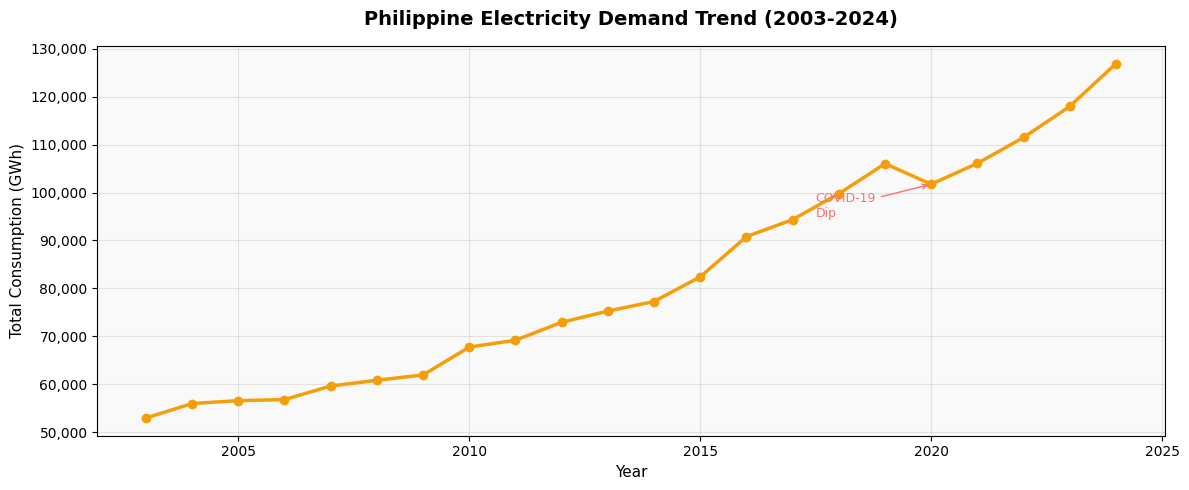

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yearly['year'], yearly['total_consumption_gwh'],
        color='#f59e0b', linewidth=2.5, marker='o', markersize=6)

# Annotate the COVID-19 dip
ax.annotate('COVID-19\nDip',
            xy=(2020, yearly.loc[yearly['year']==2020, 'total_consumption_gwh'].values[0]),
            xytext=(2017.5, 95000), fontsize=9, color='#f87171',
            arrowprops=dict(arrowstyle='->', color='#f87171'))

ax.set_title('Philippine Electricity Demand Trend (2003-2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Consumption (GWh)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('output/chart1_demand_trend.png', dpi=150)
print('✅ Chart 1 saved!')
plt.show()

---
## 📊 Part 9: Chart 2 — Regional Power Generation Bar Chart

This bar chart compares the total power generation across the three Philippine grids in 2024.

**Why Luzon dominates:**
- It contains **Metro Manila**, the most densely populated and economically active area
- Houses most of the country's industrial and commercial hubs
- Accounts for roughly **70% of total national generation**

Each bar is labeled with its exact value for easy reading.

✅ Chart 2 saved!


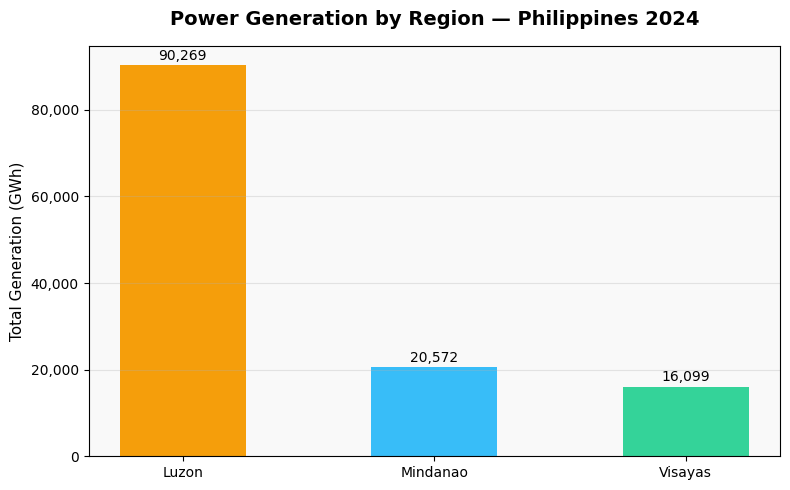

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#f59e0b', '#38bdf8', '#34d399']
bars = ax.bar(region_2024.index, region_2024.values,
              color=colors, edgecolor='none', width=0.5)

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Power Generation by Region — Philippines 2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Generation (GWh)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('output/chart2_regional.png', dpi=150)
print('✅ Chart 2 saved!')
plt.show()

---
## 🌡️ Part 10: Chart 3 — Monthly Seasonality Bar Chart

This chart shows electricity consumption per month across the Philippines in 2024.

**The peak month is highlighted in red** to make it stand out.

**Key insight:** The Philippines experiences its hottest and driest months from **March to May**, which leads to:
- Increased use of air conditioners in homes and offices
- Higher demand from cooling systems in malls, hospitals, and factories
- This pattern repeats every year, making it a **predictable seasonal trend**

✅ Chart 3 saved!


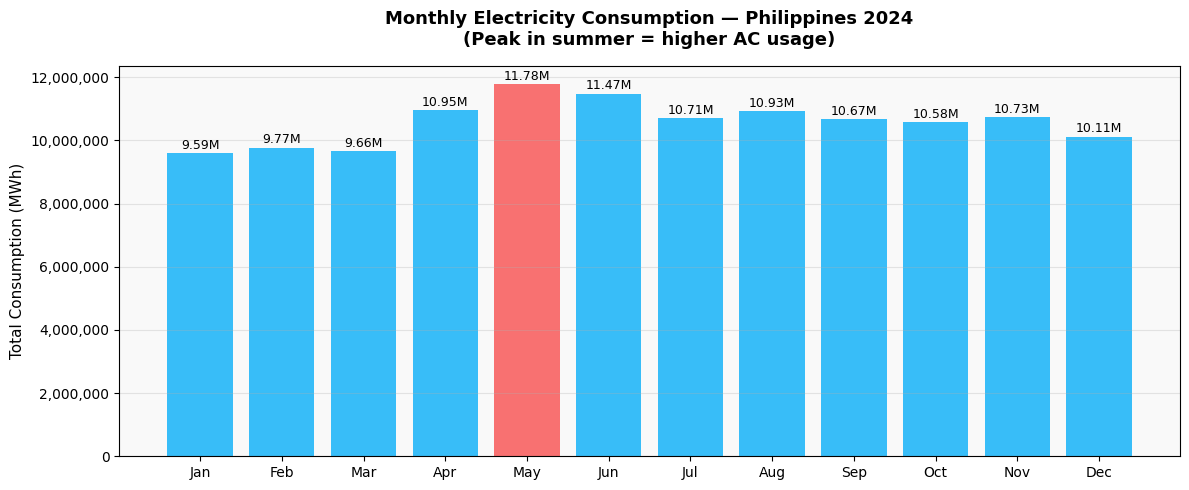

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))

# Highlight the peak month in red, rest in blue
bar_colors = ['#f87171' if v == seasonal.max() else '#38bdf8' for v in seasonal]
bars = ax.bar(month_labels, seasonal, color=bar_colors, edgecolor='none')

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50000,
            f'{bar.get_height()/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

ax.set_title('Monthly Electricity Consumption — Philippines 2024\n(Peak in summer = higher AC usage)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Total Consumption (MWh)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('output/chart3_seasonality.png', dpi=150)
print('✅ Chart 3 saved!')
plt.show()

---
## ⚡ Part 11: Bonus Chart — Coal vs Renewables Over Time

This chart tracks how the **energy mix** of the Philippines has evolved from 2003 to 2024, comparing three major sources:

- 🔴 **Coal** — the dominant source, but heavily polluting
- 🟢 **Renewables** — geothermal, hydro, solar, wind, and biomass combined
- 🔵 **Natural Gas** — a cleaner fossil fuel used as a transition energy source

**What to look for:**
- Coal has been rising sharply — this raises environmental concerns
- Renewables have remained relatively flat, but solar and wind are starting to grow
- This chart is important for understanding the Philippines' path toward clean energy

✅ Bonus Chart 4 saved!


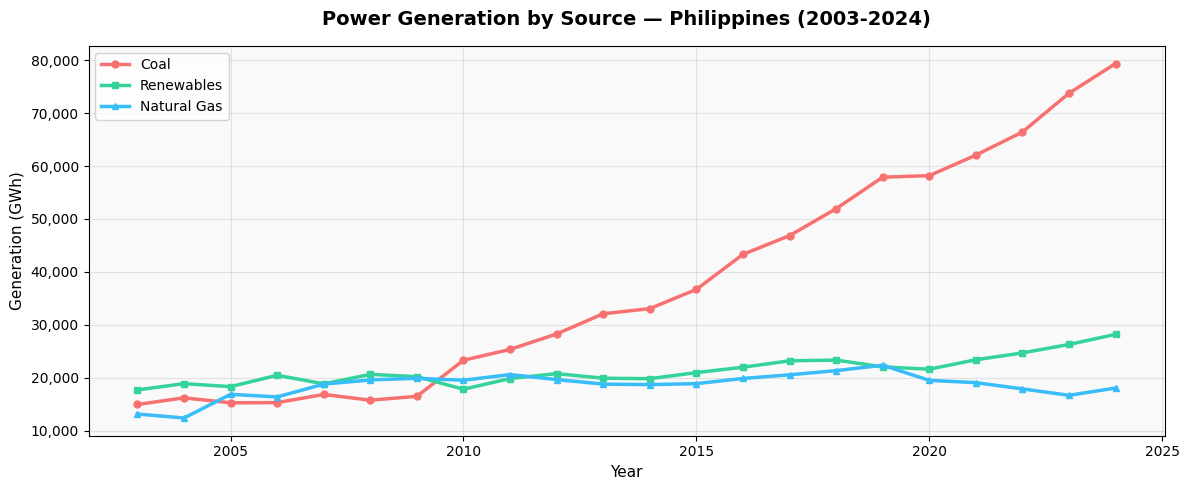

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plants['year'], plants['coal_gwh'],
        color='#f87171', linewidth=2.5, marker='o', markersize=5, label='Coal')
ax.plot(plants['year'], plants['total_re_gwh'],
        color='#34d399', linewidth=2.5, marker='s', markersize=5, label='Renewables')
ax.plot(plants['year'], plants['natural_gas_gwh'],
        color='#38bdf8', linewidth=2.5, marker='^', markersize=5, label='Natural Gas')

ax.set_title('Power Generation by Source — Philippines (2003-2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Generation (GWh)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('output/chart4_coal_vs_renewables.png', dpi=150)
print('✅ Bonus Chart 4 saved!')
plt.show()

---
## 📝 Part 12: Summary Report

Finally, we print a clean summary of all the key findings from our analysis. This is useful for:
- Quickly reviewing what the data shows without looking at charts
- Copying numbers directly into a written report or presentation
- Verifying that your analysis produced sensible results

In [60]:
print('=' * 55)
print('PHILIPPINE ENERGY CONSUMPTION — KEY INSIGHTS')
print('=' * 55)

print(f'\n📈 Demand Trend:')
print(f'   Highest year:       {yearly.loc[yearly["total_consumption_gwh"].idxmax(), "year"]}')
print(f'   Avg annual growth:  {yearly["pct_change"].mean():.1f}%')
print(f'   2020 COVID dip:     Consumption dropped to {yearly.loc[yearly["year"]==2020, "total_consumption_gwh"].values[0]:,.0f} GWh')

print(f'\n🗺️  Regional Generation (2024):')
print(f'   Top region:         {region_2024.index[0]} ({region_2024.iloc[0]:,.0f} GWh)')
print(f'   Lowest region:      {region_2024.index[-1]} ({region_2024.iloc[-1]:,.0f} GWh)')

print(f'\n📅 Peak Usage (2024):')
print(f'   Peak month:         {month_labels[peak_idx]}')
print(f'   Reason:             Summer/hot season = higher AC usage')

print(f'\n⚡ Energy Mix (2024):')
latest_plant = plants[plants['year'] == 2024].iloc[0]
total = latest_plant['total_gwh']
print(f'   Coal:               {latest_plant["coal_gwh"]:,.0f} GWh ({latest_plant["coal_gwh"]/total*100:.1f}%)')
print(f'   Renewables:         {latest_plant["total_re_gwh"]:,.0f} GWh ({latest_plant["total_re_gwh"]/total*100:.1f}%)')
print(f'   Natural Gas:        {latest_plant["natural_gas_gwh"]:,.0f} GWh ({latest_plant["natural_gas_gwh"]/total*100:.1f}%)')

print('\n✅ All charts saved in /output folder')
print('=' * 55)

PHILIPPINE ENERGY CONSUMPTION — KEY INSIGHTS

📈 Demand Trend:
   Highest year:       2024
   Avg annual growth:  4.3%
   2020 COVID dip:     Consumption dropped to 101,756 GWh

🗺️  Regional Generation (2024):
   Top region:         Luzon (90,269 GWh)
   Lowest region:      Visayas (16,099 GWh)

📅 Peak Usage (2024):
   Peak month:         May
   Reason:             Summer/hot season = higher AC usage

⚡ Energy Mix (2024):
   Coal:               79,359 GWh (62.5%)
   Renewables:         28,193 GWh (22.2%)
   Natural Gas:        18,047 GWh (14.2%)

✅ All charts saved in /output folder


---
## 💡 Conclusions & Insights

Based on the analysis, here are the key takeaways:

### 1. 📈 Electricity Demand is Growing Consistently
Philippine electricity consumption has grown steadily over the past two decades, driven by population growth, urbanization, and rising household appliance ownership. The only exception was **2020**, when the COVID-19 pandemic caused a sharp dip as lockdowns halted commercial and industrial activity.

### 2. 🗺️ Luzon Dominates National Consumption
Luzon — home to Metro Manila — accounts for the majority of total power generation and consumption. This reflects the heavy concentration of economic and industrial activity in the National Capital Region and surrounding provinces.

### 3. 🌡️ Peak Usage Occurs During Summer Months
May consistently records the highest monthly electricity consumption, coinciding with the Philippines' hottest and driest season. This puts significant stress on the power grid and highlights the need for adequate reserve capacity during peak months.

### 4. ⚠️ Coal Still Dominates the Energy Mix
Despite global shifts toward clean energy, coal remains the dominant power source in the Philippines, accounting for over 60% of total generation. Coal accounts for 62.5% of total generation in 2024, up from 28% in 2003 — a more than doubling in share despite global clean energy commitments. Renewable energy growth has been slow, though solar and wind capacity is beginning to expand.

---

### 🚀 Possible Next Steps
- Forecast electricity demand for 2025–2030 using trend analysis
- Correlate energy consumption with GDP or population growth
- Analyze the growth rate of solar energy specifically
- Compare Philippine per capita consumption with neighboring ASEAN countries

---
*Data Source: Department of Energy Philippines — 2024 Power Statistics | doe.gov.ph*